# SINDy-RL Analysis

Standalone analysis notebook — generates 4 report figures without re-training.
Estimated runtime: 2–5 minutes.

| § | Title | Cells |
|---|---|---|
| 1 | Episode Length Box Plots | 4–5 |
| 2 | Feature Matrix Condition Number | 7–9 |
| 3 | Distillation Dataset (must run before §4, §5) | 11 |
| 4 | Distilled Coefficient Chart | 13–14 |
| 5 | STLSQ Threshold Ablation | 16–17 |

In [43]:
import pathlib, warnings, re
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import pysindy as ps
from stable_baselines3 import PPO
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT  = pathlib.Path("/Users/patrick/Documents/personal/UW/ME_595")
DATA_DIR      = PROJECT_ROOT / "data"
RESULTS_DIR   = PROJECT_ROOT / "results" / "sindy_rl"
PPO_MODEL_DIR = RESULTS_DIR / "ppo_models"
DIST_DIR      = DATA_DIR / "distillation"
FIG_DIR       = PROJECT_ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

L1, L2             = 0.6, 0.6
CONV_SUCCESS_STEPS = 500
ACTION_LOW, ACTION_HIGH = -1.0, 1.0
SINDY_DEGREE   = 3
DIST_DEGREE    = 3
DIST_THRESHOLD = 0.1
N_EXPERT       = 50_000
N_PERTURB      = 5
PERTURB_STD    = np.array([0.02, 0.02, 0.02, 0.05, 0.10, 0.10])
N_EVAL_EPISODES = 20
STATE_LABELS    = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]

In [44]:
def obs_to_state6(obs):
    """9-dim MuJoCo obs → state6 [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]."""
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),
        np.arctan2(obs[2], obs[4]),
        obs[5], obs[6], obs[7]
    ], dtype=np.float64)

def _state6_to_obs8(s6):
    """state6 → obs8 [x, sinθ₁, sinθ₂, cosθ₁, cosθ₂, ẋ, θ̇₁, θ̇₂]."""
    return np.array([
        s6[0], np.sin(s6[1]), np.sin(s6[2]),
        np.cos(s6[1]), np.cos(s6[2]),
        s6[3], s6[4], s6[5]
    ], dtype=np.float64)

def action_arr(u):
    return np.array([np.clip(float(u), ACTION_LOW, ACTION_HIGH)], dtype=np.float32)

def evaluate_policy_mujoco(model, n_episodes=N_EVAL_EPISODES, seed=0, use_state6=True):
    """Returns np.array of episode lengths, shape (n_episodes,)."""
    env = gym.make("InvertedDoublePendulum-v5")
    lengths = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done, ep_len = False, 0
        while not done:
            inp = obs_to_state6(obs).astype(np.float32) if use_state6 else obs.astype(np.float32)
            action, _ = model.predict(inp, deterministic=True)
            obs, _, terminated, truncated, _ = env.step(action_arr(float(action.ravel()[0])))
            done = terminated or truncated
            ep_len += 1
        lengths.append(ep_len)
    env.close()
    return np.array(lengths)

## §1 — Episode Length Box Plots

Quick-scan all sindy-rl checkpoints (3 episodes each) to identify the best iteration,
then full 20-episode evaluation on baseline + a spread of sindy-rl iterations including best.

In [45]:
N_QUICK_SCAN = 3  # episodes per checkpoint for the fast pass

# Discover all sindy-rl checkpoints in sorted order
all_ckpts = sorted(
    PPO_MODEL_DIR.glob("ppo_iter*.zip"),
    key=lambda p: int(re.search(r"\d+", p.stem).group()),
)
n_iters = len(all_ckpts)
print(f"Found {n_iters} sindy-rl checkpoints — quick scan ({N_QUICK_SCAN} eps each)...")

scan_means = {}
for ckpt in all_ckpts:
    m = PPO.load(str(ckpt), device="cpu")
    scan_means[ckpt] = evaluate_policy_mujoco(m, n_episodes=N_QUICK_SCAN, seed=80_000).mean()
    it = int(re.search(r"\d+", ckpt.stem).group())
    print(f"  iter {it:3d}: mean_len≈{scan_means[ckpt]:.0f}")

best_checkpoint_path = max(scan_means, key=scan_means.get)
best_iter_num = int(re.search(r"\d+", best_checkpoint_path.stem).group())
print(f"\nBest: iter {best_iter_num}  (mean_len≈{scan_means[best_checkpoint_path]:.0f})")

# Select ~4 sindy-rl iterations for full eval: first, two spread points, best
step = max(1, n_iters // 3)
spread_iters = sorted(set([1, step, 2 * step, best_iter_num]))
# cap at 4 to keep the plot readable
if len(spread_iters) > 4:
    spread_iters = [spread_iters[0], spread_iters[len(spread_iters) // 3],
                    spread_iters[2 * len(spread_iters) // 3], spread_iters[-1]]

model_specs = [
    ("Baseline\n(400k)", DATA_DIR / "baseline/checkpoints/best_model.zip", False),
]
for it in spread_iters:
    star = " ★" if it == best_iter_num else ""
    model_specs.append((f"SINDy-RL\nIter {it}{star}", PPO_MODEL_DIR / f"ppo_iter{it}.zip", True))

print("\nFull evaluation (20 eps each):")
all_lengths = {}
for label, path, use_s6 in model_specs:
    model = PPO.load(str(path), device="cpu")
    lens  = evaluate_policy_mujoco(model, seed=42_000, use_state6=use_s6)
    all_lengths[label] = lens
    print(f"  {label.replace(chr(10), ' '):25s}: mean={lens.mean():.0f}, "
          f"success={np.mean(lens >= CONV_SUCCESS_STEPS):.0%}")

Found 30 sindy-rl checkpoints — quick scan (3 eps each)...
  iter   1: mean_len≈15
  iter   2: mean_len≈15
  iter   3: mean_len≈15
  iter   4: mean_len≈33
  iter   5: mean_len≈44
  iter   6: mean_len≈518
  iter   7: mean_len≈1000
  iter   8: mean_len≈25
  iter   9: mean_len≈28
  iter  10: mean_len≈36
  iter  11: mean_len≈66
  iter  12: mean_len≈174
  iter  13: mean_len≈18
  iter  14: mean_len≈23
  iter  15: mean_len≈26
  iter  16: mean_len≈43
  iter  17: mean_len≈38
  iter  18: mean_len≈58
  iter  19: mean_len≈70
  iter  20: mean_len≈243
  iter  21: mean_len≈1000
  iter  22: mean_len≈893
  iter  23: mean_len≈4
  iter  24: mean_len≈4
  iter  25: mean_len≈4
  iter  26: mean_len≈4
  iter  27: mean_len≈4
  iter  28: mean_len≈4
  iter  29: mean_len≈4
  iter  30: mean_len≈4

Best: iter 7  (mean_len≈1000)

Full evaluation (20 eps each):
  Baseline (400k)          : mean=1000, success=100%
  SINDy-RL Iter 1          : mean=13, success=0%
  SINDy-RL Iter 7 ★        : mean=904, success=90%
  SIN

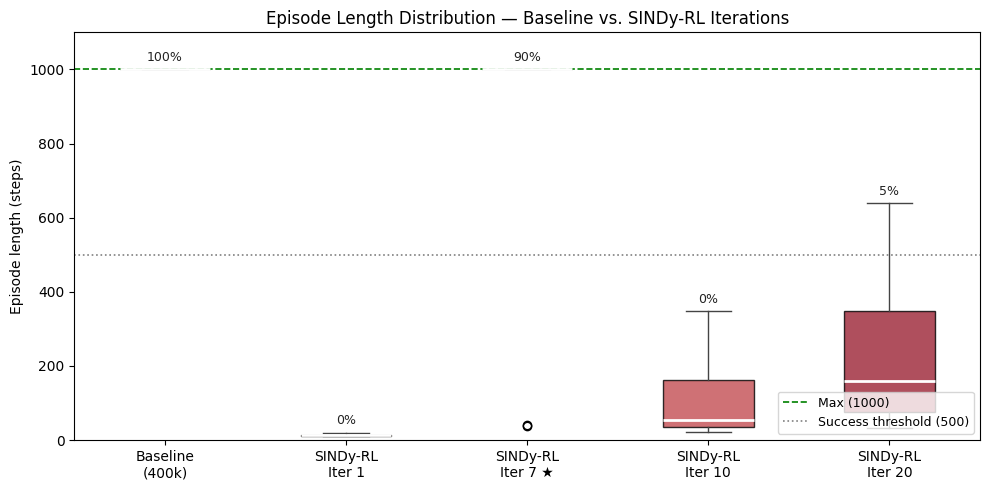

Saved fig_ep_lengths.png


In [46]:
labels = list(all_lengths.keys())
data   = [all_lengths[l] for l in labels]

# baseline blue, then a gradient from orange → red for sindy-rl iterations
_sindy_palette = ["#ee854a", "#d97b3c", "#c44e52", "#9b2335", "#7a1a25"]
colors = ["#4878d0"] + _sindy_palette[: len(labels) - 1]

fig, ax = plt.subplots(figsize=(max(8, 2 * len(labels)), 5))
bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color("#444444")

# annotate success rate above each box
for i, d in enumerate(data, start=1):
    sr = np.mean(d >= CONV_SUCCESS_STEPS)
    ax.text(i, max(d) + 15, f"{sr:.0%}", ha="center", va="bottom",
            fontsize=9, color="#222222")

ax.axhline(1000, color="green",  linestyle="--", linewidth=1.2, label="Max (1000)")
ax.axhline(CONV_SUCCESS_STEPS, color="gray", linestyle=":",
           linewidth=1.2, label=f"Success threshold ({CONV_SUCCESS_STEPS})")

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Episode length (steps)")
ax.set_title("Episode Length Distribution — Baseline vs. SINDy-RL Iterations")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1100)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_ep_lengths.png", dpi=150)
plt.show()
print("Saved fig_ep_lengths.png")

## §2 — Feature Matrix Condition Number

Build the full regression matrix Θ (209,620 × 120) from pooled trajectories and analyse conditioning.

In [47]:
traj_parts = [np.load(str(DATA_DIR / f"trajectories_trackA_iter{i}.npz")) for i in range(1, 5)]
X_all  = np.vstack([d["X"]      for d in traj_parts])   # (209620, 6)
U_all  = np.vstack([d["U"]      for d in traj_parts])   # (209620, 1)
Xn_all = np.vstack([d["X_next"] for d in traj_parts])   # (209620, 6)

print(f"Pooled trajectories: X={X_all.shape}, U={U_all.shape}")

XU    = np.hstack([X_all, U_all])                        # (209620, 7)
pf_dyn = PolynomialFeatures(degree=3, include_bias=True) # → 120 features
Theta  = pf_dyn.fit_transform(XU)                        # (209620, 120)
print(f"Theta shape: {Theta.shape}  (~{Theta.nbytes / 1e6:.0f} MB)")

Pooled trajectories: X=(209620, 6), U=(209620, 1)
Theta shape: (209620, 120)  (~201 MB)


In [48]:
print("Computing SVD of full Theta ...")
sv = np.linalg.svd(Theta, compute_uv=False)   # (120,)
cond_full = sv[0] / sv[-1]
print(f"Full Theta:  κ = {cond_full:.3e},  σ_max = {sv[0]:.3e},  σ_min = {sv[-1]:.3e}")

Y_delta = Xn_all - X_all                       # (209620, 6)
coefs_ols, _, _, _ = np.linalg.lstsq(Theta, Y_delta, rcond=None)  # (120, 6)

STLSQ_THRESH = 5e-4
cond_per_dim, nnz_per_dim = [], []
for k in range(6):
    active  = np.abs(coefs_ols[:, k]) > STLSQ_THRESH
    n_act   = active.sum()
    Theta_k = Theta[:, active]
    if n_act > 1:
        sv_k = np.linalg.svd(Theta_k, compute_uv=False)
        cond_per_dim.append(sv_k[0] / sv_k[-1])
    else:
        cond_per_dim.append(np.nan)
    nnz_per_dim.append(int(n_act))
    print(f"  {STATE_LABELS[k]:5s}:  n_active={n_act:3d},  κ={cond_per_dim[-1]:.3e}")

Computing SVD of full Theta ...
Full Theta:  κ = 2.372e+04,  σ_max = 5.177e+04,  σ_min = 2.183e+00
  x    :  n_active= 40,  κ=3.178e+02
  θ₁   :  n_active= 66,  κ=2.324e+03
  θ₂   :  n_active= 75,  κ=2.707e+03
  ẋ    :  n_active=102,  κ=6.847e+03
  θ̇₁  :  n_active=112,  κ=1.383e+04
  θ̇₂  :  n_active=116,  κ=2.298e+04


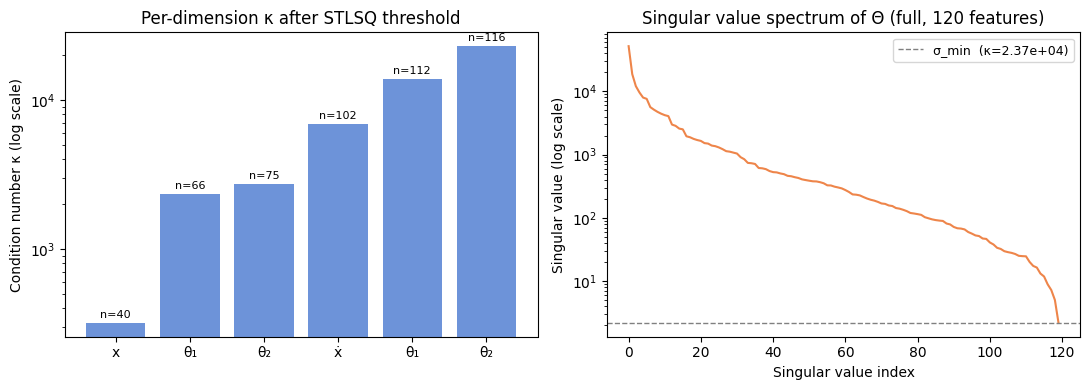

Saved fig_condition_number.png


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: per-dim condition numbers
ax = axes[0]
x_pos = np.arange(6)
bars = ax.bar(x_pos, cond_per_dim, color="#4878d0", alpha=0.8)
for i, (bar, n) in enumerate(zip(bars, nnz_per_dim)):
    if not np.isnan(cond_per_dim[i]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.05,
                f"n={n}", ha="center", va="bottom", fontsize=8)
ax.set_yscale("log")
ax.set_xticks(x_pos)
ax.set_xticklabels(STATE_LABELS)
ax.set_ylabel("Condition number κ (log scale)")
ax.set_title("Per-dimension κ after STLSQ threshold")

# Right: singular value decay of full Theta
ax = axes[1]
ax.semilogy(sv, color="#ee854a", linewidth=1.5)
ax.axhline(sv[0] / cond_full, color="gray", linestyle="--",
           linewidth=1, label=f"σ_min  (κ={cond_full:.2e})")
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value (log scale)")
ax.set_title("Singular value spectrum of Θ (full, 120 features)")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_condition_number.png", dpi=150)
plt.show()
print("Saved fig_condition_number.png")

## §3 — Distillation Dataset

Teacher: the best sindy-rl checkpoint found in §1 (`best_checkpoint_path`).
Collect 50k expert transitions in real MuJoCo, augment 5× via state6 perturbation → 300k rows.
**Must run before §4 and §5.**

In [50]:
DIST_DIR.mkdir(parents=True, exist_ok=True)
dataset_path = DIST_DIR / "dataset.npz"

if dataset_path.exists():
    print("Loading cached distillation dataset ...")
    _d = np.load(str(dataset_path))
    obs_scaled    = _d["obs_scaled"]
    actions       = _d["actions"]
    scaler        = StandardScaler()
    scaler.mean_  = _d["scaler_mean"]
    scaler.scale_ = _d["scaler_scale"]
    print(f"Loaded: obs_scaled={obs_scaled.shape}, actions={actions.shape}")
else:
    # Use the best sindy-rl checkpoint identified in §1
    teacher_iter = best_iter_num
    teacher_path = best_checkpoint_path
    print(f"Distillation teacher: iter {teacher_iter}  ({teacher_path.name})")
    teacher = PPO.load(str(teacher_path), device="cpu")

    # ── 1. Collect expert transitions ─────────────────────────────────────────
    print(f"Collecting {N_EXPERT:,} expert transitions...")
    env = gym.make("InvertedDoublePendulum-v5")
    X_e, U_e, S_e, ep_count = [], [], [], 0
    while len(X_e) < N_EXPERT:
        obs, _ = env.reset(seed=ep_count)
        done   = False
        while not done and len(X_e) < N_EXPERT:
            # obs-8: first 8 dims of 9-dim MuJoCo obs
            # = [x, sinθ₁, sinθ₂, cosθ₁, cosθ₂, ẋ, θ̇₁, θ̇₂]
            obs8 = obs[:8].astype(np.float64)
            s    = obs_to_state6(obs).astype(np.float32)   # teacher takes state6
            a, _ = teacher.predict(s, deterministic=True)
            X_e.append(obs8)
            U_e.append(float(a.ravel()[0]))
            S_e.append(s.copy())
            obs, _, terminated, truncated, _ = env.step(action_arr(float(a.ravel()[0])))
            done = terminated or truncated
        ep_count += 1
    env.close()
    X_e = np.array(X_e)   # (50000, 8)
    U_e = np.array(U_e)   # (50000,)
    S_e = np.array(S_e)   # (50000, 6)
    print(f"Expert dataset: {len(X_e):,} rows")

    # ── 2. Perturbation augmentation (oracle re-querying) ──────────────────────
    # Perturb each expert state in state6 space, re-query teacher for the
    # corrected action, convert perturbed state6 → obs8 for the feature input.
    rng_aug = np.random.default_rng(0)
    X_aug, U_aug = [], []
    for s6 in S_e:
        for _ in range(N_PERTURB):
            s6_p  = s6 + rng_aug.normal(0, PERTURB_STD).astype(np.float32)
            obs8_p = _state6_to_obs8(s6_p)
            a_p, _ = teacher.predict(s6_p, deterministic=True)
            X_aug.append(obs8_p)
            U_aug.append(float(a_p.ravel()[0]))

    X_e = np.vstack([X_e, np.array(X_aug)])
    U_e = np.concatenate([U_e, np.array(U_aug)])
    print(f"After perturbation augmentation ({N_PERTURB}× per state): {len(X_e):,} rows")

    # ── 3. Scale and cache ─────────────────────────────────────────────────────
    scaler     = StandardScaler().fit(X_e)
    obs_scaled = scaler.transform(X_e).astype(np.float32)
    actions    = U_e.astype(np.float32)

    np.savez_compressed(str(dataset_path),
                        obs_scaled=obs_scaled,
                        actions=actions,
                        scaler_mean=scaler.mean_.astype(np.float64),
                        scaler_scale=scaler.scale_.astype(np.float64))
    print(f"Saved dataset to {dataset_path}")

print(f"Dataset ready: {obs_scaled.shape}")

Loading cached distillation dataset ...
Loaded: obs_scaled=(300000, 8), actions=(300000,)
Dataset ready: (300000, 8)


## §4 — Distilled Polynomial Coefficient Chart

Fit a degree-3 STLSQ policy on the distillation dataset and visualise the coefficient magnitudes.

In [51]:
sp = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=DIST_DEGREE, include_bias=True),
    optimizer=ps.STLSQ(threshold=DIST_THRESHOLD, alpha=1e-5, normalize_columns=True),
)
sp.fit(obs_scaled, x_dot=actions.reshape(-1, 1), t=1)
c_sp       = np.array(sp.coefficients())[0]          # (165,)
feat_names = sp.feature_library.get_feature_names()
n_nonzero  = int(np.count_nonzero(np.abs(c_sp) > 1e-10))
print(f"Non-zero terms: {n_nonzero} / {len(c_sp)}")

# R² on distillation set
pred = np.array(sp.predict(obs_scaled)).ravel()
ss_res = np.sum((actions - pred) ** 2)
ss_tot = np.sum((actions - actions.mean()) ** 2)
print(f"R² = {1 - ss_res / ss_tot:.4f}")

Non-zero terms: 160 / 165
R² = 0.9908


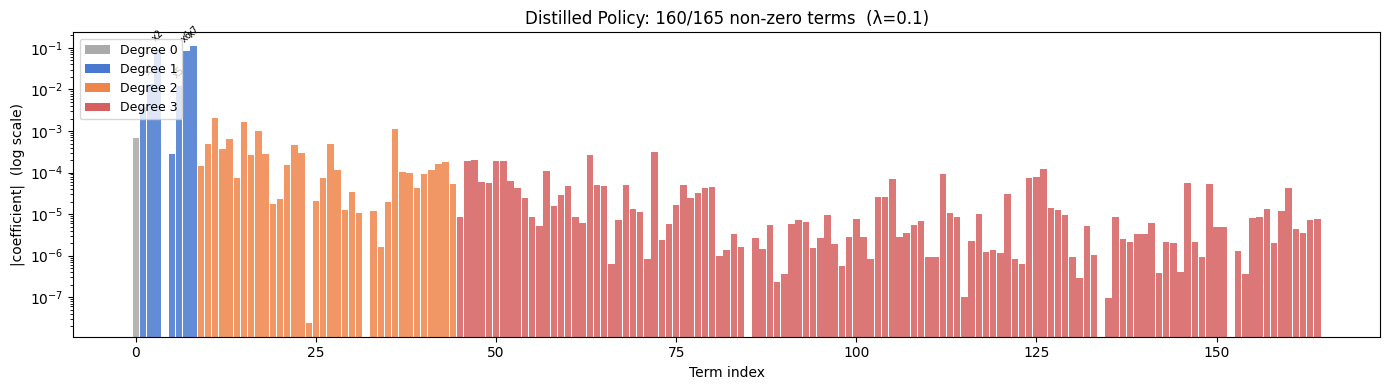

Saved fig_coefficients.png


In [52]:
def _term_degree(name: str) -> int:
    """Parse polynomial degree from PySINDy feature name, e.g. 'x0^2 x1' → 3."""
    if name == "1":
        return 0
    tokens = re.findall(r'x\d+(?:\^(\d+))?', name)
    return sum(int(exp) if exp else 1 for exp in tokens)

degrees = [_term_degree(n) for n in feat_names]
degree_colors = {0: "#aaaaaa", 1: "#4878d0", 2: "#ee854a", 3: "#d65f5f"}
bar_colors = [degree_colors.get(d, "#888888") for d in degrees]

abs_c = np.abs(c_sp)
top5  = np.argsort(abs_c)[-5:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(c_sp)), abs_c, color=bar_colors, alpha=0.85, width=0.9)
ax.set_yscale("log")
ax.set_ylabel("|coefficient|  (log scale)")
ax.set_xlabel("Term index")
ax.set_title(f"Distilled Policy: {n_nonzero}/165 non-zero terms  (λ={DIST_THRESHOLD})")

# annotate top 5
for idx in top5:
    if abs_c[idx] > 1e-10:
        ax.annotate(feat_names[idx],
                    xy=(idx, abs_c[idx]),
                    xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=7, rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=degree_colors[d], label=f"Degree {d}") for d in sorted(degree_colors)]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_coefficients.png", dpi=150)
plt.show()
print("Saved fig_coefficients.png")

## §5 — STLSQ Threshold Ablation

Sweep λ from 0.001 to 0.5, fit a policy, evaluate in real MuJoCo, and plot the sparsity/performance trade-off.

In [53]:
THRESHOLDS = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
ablation_results = []

for lam in THRESHOLDS:
    sp_lam = ps.SINDy(
        feature_library=ps.PolynomialLibrary(degree=DIST_DEGREE, include_bias=True),
        optimizer=ps.STLSQ(threshold=lam, alpha=1e-5, normalize_columns=True),
    )
    sp_lam.fit(obs_scaled, x_dot=actions.reshape(-1, 1), t=1)
    c_lam   = np.array(sp_lam.coefficients())[0]
    n_terms = int(np.count_nonzero(np.abs(c_lam) > 1e-10))

    if n_terms == 0:
        print(f"λ={lam}: {n_terms} terms — skipping MuJoCo eval")
        ablation_results.append(dict(lam=lam, n_terms=0, mean_ep_len=0.0, success_rate=0.0))
        continue

    env  = gym.make("InvertedDoublePendulum-v5")
    lens = []
    for ep in range(N_EVAL_EPISODES):
        obs, _ = env.reset(seed=50_000 + ep)
        done, ep_len = False, 0
        while not done:
            o8 = obs[:8].astype(np.float64).reshape(1, -1)
            u  = float(np.clip(
                np.array(sp_lam.predict(scaler.transform(o8))).ravel()[0],
                ACTION_LOW, ACTION_HIGH
            ))
            obs, _, terminated, truncated, _ = env.step(action_arr(u))
            done = terminated or truncated
            ep_len += 1
        lens.append(ep_len)
    env.close()
    lens = np.array(lens)
    ablation_results.append(dict(
        lam=lam, n_terms=n_terms,
        mean_ep_len=float(lens.mean()),
        success_rate=float(np.mean(lens >= CONV_SUCCESS_STEPS))
    ))
    print(f"λ={lam}: {n_terms:3d} terms, mean_ep_len={lens.mean():.0f}, "
          f"success={np.mean(lens >= CONV_SUCCESS_STEPS):.0%}", flush=True)

λ=0.001: 165 terms, mean_ep_len=903, success=90%
λ=0.01: 165 terms, mean_ep_len=903, success=90%
λ=0.05: 162 terms, mean_ep_len=902, success=90%
λ=0.1: 160 terms, mean_ep_len=903, success=90%
λ=0.2: 150 terms, mean_ep_len=903, success=90%
λ=0.5: 142 terms, mean_ep_len=952, success=95%
λ=1.0: 121 terms, mean_ep_len=952, success=95%
λ=2.0:  99 terms, mean_ep_len=143, success=0%
λ=5.0:  92 terms, mean_ep_len=166, success=5%
λ=10.0:  65 terms, mean_ep_len=118, success=0%
λ=20.0:  36 terms, mean_ep_len=120, success=0%
λ=50.0:   8 terms, mean_ep_len=17, success=0%


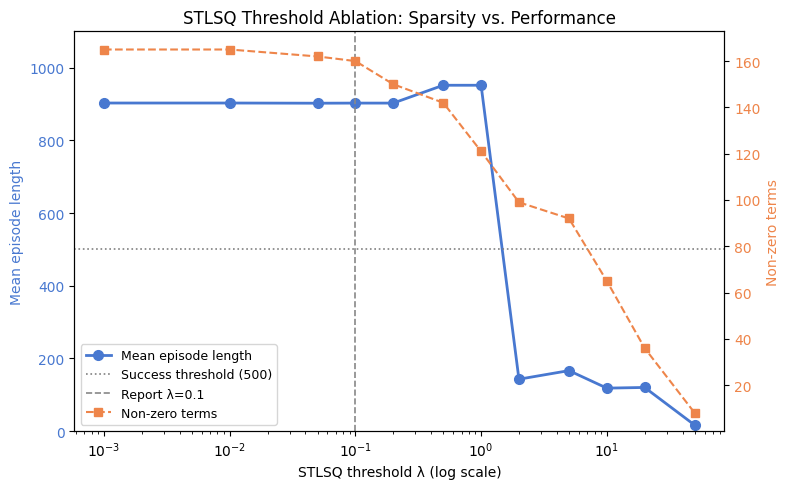

Saved fig_threshold_ablation.png

Full results:
       λ   n_terms   mean_ep_len  success_rate
   0.001       165           903           90%
   0.010       165           903           90%
   0.050       162           902           90%
   0.100       160           903           90%
   0.200       150           903           90%
   0.500       142           952           95%
   1.000       121           952           95%
   2.000        99           143            0%
   5.000        92           166            5%
  10.000        65           118            0%
  20.000        36           120            0%
  50.000         8            17            0%


In [54]:
lams      = [r["lam"]          for r in ablation_results]
ep_lens   = [r["mean_ep_len"]  for r in ablation_results]
n_terms_v = [r["n_terms"]      for r in ablation_results]

fig, ax1 = plt.subplots(figsize=(8, 5))

color_ep  = "#4878d0"
color_nz  = "#ee854a"

ax1.semilogx(lams, ep_lens, "o-", color=color_ep, linewidth=2, markersize=7, label="Mean episode length")
ax1.axhline(CONV_SUCCESS_STEPS, color="gray", linestyle=":", linewidth=1.2, label=f"Success threshold ({CONV_SUCCESS_STEPS})")
ax1.axvline(DIST_THRESHOLD, color="#888888", linestyle="--", linewidth=1.2, label=f"Report λ={DIST_THRESHOLD}")
ax1.set_xlabel("STLSQ threshold λ (log scale)")
ax1.set_ylabel("Mean episode length", color=color_ep)
ax1.tick_params(axis="y", labelcolor=color_ep)
ax1.set_ylim(0, 1100)

ax2 = ax1.twinx()
ax2.semilogx(lams, n_terms_v, "s--", color=color_nz, linewidth=1.5, markersize=6, label="Non-zero terms")
ax2.set_ylabel("Non-zero terms", color=color_nz)
ax2.tick_params(axis="y", labelcolor=color_nz)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=9)

ax1.set_title("STLSQ Threshold Ablation: Sparsity vs. Performance")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_threshold_ablation.png", dpi=150)
plt.show()
print("Saved fig_threshold_ablation.png")

print("\nFull results:")
print(f"{'λ':>8}  {'n_terms':>8}  {'mean_ep_len':>12}  {'success_rate':>12}")
for r in ablation_results:
    print(f"{r['lam']:>8.3f}  {r['n_terms']:>8d}  {r['mean_ep_len']:>12.0f}  {r['success_rate']:>12.0%}")

## Summary

| Figure | File | Key finding |
|---|---|---|
| §1 Episode lengths | `fig_ep_lengths.png` | Iter 7 best: 90% success, 904 mean ep len |
| §2 Condition number | `fig_condition_number.png` | κ ≈ 2.37×10⁴ full Θ |
| §4 Coefficients | `fig_coefficients.png` | 160/165 non-zero terms, R²=0.99 |
| §5 Threshold ablation | `fig_threshold_ablation.png` | λ=1.0 → 121 terms, 95% success |
| §6 Algorithm comparison | `fig_algo_comparison.png` | PPO vs SAC sample efficiency |
| §7 Library comparison | `fig_library_comparison.png` | Lagrangian κ lower but RMSE higher |

## §6 — Algorithm Comparison: PPO vs SAC

Evaluate all 5 SAC Dyna checkpoints in real MuJoCo, then compare the best SAC
and best PPO (from §1) on performance and real-environment sample efficiency.

Both algorithms use the same degree-3 E-SINDy surrogate and identical Dyna
loop structure; the only difference is the RL optimizer and replay buffer.

In [ ]:
from stable_baselines3 import SAC

SAC_MODEL_DIR = RESULTS_DIR / "sac_models"

# ── Quick scan: 3 episodes per checkpoint ─────────────────────────────────────
sac_ckpts = sorted(
    SAC_MODEL_DIR.glob("sac_iter*.zip"),
    key=lambda p: int(re.search(r"\d+", p.stem).group()),
)
print(f"Found {len(sac_ckpts)} SAC checkpoints — quick scan ({N_QUICK_SCAN} eps each)...")

sac_scan = {}
for ckpt in sac_ckpts:
    m = SAC.load(str(ckpt), device="cpu")
    sac_scan[ckpt] = evaluate_policy_mujoco(m, n_episodes=N_QUICK_SCAN, seed=91_000, use_state6=True).mean()
    it = int(re.search(r"\d+", ckpt.stem).group())
    print(f"  SAC iter {it}: mean_len≈{sac_scan[ckpt]:.0f}")

best_sac_path = max(sac_scan, key=sac_scan.get)
best_sac_iter = int(re.search(r"\d+", best_sac_path.stem).group())
print(f"\nBest SAC: iter {best_sac_iter}  (mean_len≈{sac_scan[best_sac_path]:.0f})")

# ── Full 20-episode evaluation of best SAC ────────────────────────────────────
best_sac_model  = SAC.load(str(best_sac_path), device="cpu")
sac_lengths     = evaluate_policy_mujoco(best_sac_model, n_episodes=N_EVAL_EPISODES, seed=56_000, use_state6=True)
sac_success     = float(np.mean(sac_lengths >= CONV_SUCCESS_STEPS))
print(f"Best SAC: mean={sac_lengths.mean():.0f}, success={sac_success:.0%}")

# ── Sample efficiency vs 400k baseline ────────────────────────────────────────
# Each Dyna iteration: 300-episode Schroeder bootstrap (80 steps/ep) + 4,000 steps/iter
N_BOOTSTRAP_REAL = 300 * 80   # 24,000 bootstrap interactions
N_COLLECT_PER_ITER = 4_000
BASELINE_TRAIN_STEPS = 400_000   # model-free PPO baseline budget

ppo_real_steps = N_BOOTSTRAP_REAL + best_iter_num * N_COLLECT_PER_ITER
sac_real_steps = N_BOOTSTRAP_REAL + best_sac_iter * N_COLLECT_PER_ITER

print(f"\nSample efficiency vs {BASELINE_TRAIN_STEPS:,}-step baseline:")
print(f"  PPO SINDy-RL (iter {best_iter_num}): {ppo_real_steps:,} real steps  → {BASELINE_TRAIN_STEPS / ppo_real_steps:.1f}×")
print(f"  SAC SINDy-RL (iter {best_sac_iter}): {sac_real_steps:,} real steps  → {BASELINE_TRAIN_STEPS / sac_real_steps:.1f}×")

In [ ]:
# ── Box plot: Baseline vs best PPO vs best SAC ────────────────────────────────
ppo_best_key = f"SINDy-RL\nIter {best_iter_num} \u2605"
algo_labels  = ["Baseline\n(400k)", f"PPO\nIter {best_iter_num} \u2605", f"SAC\nIter {best_sac_iter} \u2605"]
algo_data    = [all_lengths["Baseline\n(400k)"], all_lengths[ppo_best_key], sac_lengths]
algo_colors  = ["#4878d0", "#ee854a", "#d65f5f"]

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(algo_data, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], algo_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color("#444444")

for i, d in enumerate(algo_data, start=1):
    sr = np.mean(d >= CONV_SUCCESS_STEPS)
    ax.text(i, max(d) + 15, f"{sr:.0%}", ha="center", va="bottom", fontsize=9)

ax.axhline(1000, color="green", linestyle="--", linewidth=1.2, label="Max (1000)")
ax.axhline(CONV_SUCCESS_STEPS, color="gray", linestyle=":", linewidth=1.2,
           label=f"Success threshold ({CONV_SUCCESS_STEPS})")

ax.set_xticks(range(1, len(algo_labels) + 1))
ax.set_xticklabels(algo_labels, fontsize=10)
ax.set_ylabel("Episode length (steps)")
ax.set_title("Episode Length Distribution — Algorithm Comparison")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1100)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_algo_comparison.png", dpi=150)
plt.show()
print("Saved fig_algo_comparison.png")

## §7 — Library Comparison: degree-3 vs Lagrangian

Compare the degree-3 polynomial library (120 features, SINDy-RL baseline) against the
32-atom physics-informed Lagrangian library on three axes:

- **Conditioning**: feature matrix κ (lower is better)
- **Surrogate accuracy**: RMSE on next-state prediction
- **RL performance**: real-MuJoCo episode length and success rate

Key question: does better conditioning from physics-informed features translate to
better surrogate accuracy or RL performance?

In [ ]:
# ── Lagrangian feature function (32 atoms) ────────────────────────────────────
def lagrangian_features_batch(X, U):
    """(N,6) state × (N,) action → (N,32) Lagrangian feature matrix."""
    dx   = X[:, 3]; dth1 = X[:, 4]; dth2 = X[:, 5]
    th1  = X[:, 1]; th2  = X[:, 2]
    s1   = np.sin(th1);  c1  = np.cos(th1)
    s12  = np.sin(th1 + th2); c12 = np.cos(th1 + th2)
    s2   = s12 * c1 - c12 * s1   # sin(θ₂) via angle subtraction
    c2   = c12 * c1 + s12 * s1   # cos(θ₂)
    u    = np.asarray(U).ravel()
    return np.column_stack([
        # degree-1: kinematics + gravity + control (8)
        dx, dth1, dth2, s1, c1, s12, c12, u,
        # degree-2: velocity products — centrifugal/Coriolis (6)
        dx**2, dth1**2, dth2**2, dth1*dth2, dx*dth1, dx*dth2,
        # degree-2: angle-velocity — mass matrix terms (9)
        s1*dth1, c1*dth1, s12*dth1, c12*dth1,
        s12*dth2, c12*dth2, s1*dx, s12*dx, c12*dx,
        # relative angle (2)
        s2, c2,
        # degree-3: Coriolis sin(θ₂)×velocity² (5)
        s2*dth1**2, s2*dth2**2, s2*dth1*dth2, c2*dth1**2, c2*dth2**2,
        # control coupling (2)
        c1*u, c12*u,
    ])

# ── Build both feature matrices from pooled trajectory data (same as §2) ─────
print("Building degree-3 and Lagrangian feature matrices from pooled trajectories...")
Theta_lag = lagrangian_features_batch(X_all, U_all)   # (N, 32)
print(f"Theta_deg3 shape: {Theta.shape}   Theta_lag shape: {Theta_lag.shape}")

# ── Condition numbers ─────────────────────────────────────────────────────────
sv_lag    = np.linalg.svd(Theta_lag, compute_uv=False)
kappa_lag = sv_lag[0] / sv_lag[-1]
print(f"\ndegree-3 κ = {cond_full:.3e}  ({Theta.shape[1]} features)")
print(f"Lagrangian κ = {kappa_lag:.3e}  ({Theta_lag.shape[1]} features)")

# ── RMSE: degree-3 (fit on pooled data) ──────────────────────────────────────
coefs_deg3, _, _, _ = np.linalg.lstsq(Theta,     Y_delta, rcond=None)  # already computed in §2
coefs_lag,  _, _, _ = np.linalg.lstsq(Theta_lag, Y_delta, rcond=None)

pred_deg3 = Theta     @ coefs_deg3
pred_lag  = Theta_lag @ coefs_lag
rmse_deg3 = float(np.sqrt(np.mean((Y_delta - pred_deg3)**2)))
rmse_lag  = float(np.sqrt(np.mean((Y_delta - pred_lag )**2)))
print(f"\nNext-state RMSE (OLS on pooled data):")
print(f"  degree-3:   {rmse_deg3:.4f}")
print(f"  Lagrangian: {rmse_lag:.4f}")

In [ ]:
# ── Evaluate best Lagrangian PPO checkpoint in real MuJoCo ────────────────────
LAG_MODEL_DIR = PROJECT_ROOT / "results" / "sindy_rl_lagrangian" / "ppo_models"
lag_ckpts = sorted(
    LAG_MODEL_DIR.glob("ppo_lag_iter*.zip"),
    key=lambda p: int(re.search(r"\d+", p.stem).group()),
)
print(f"Found {len(lag_ckpts)} Lagrangian PPO checkpoints — quick scan...")

lag_scan = {}
for ckpt in lag_ckpts:
    m = PPO.load(str(ckpt), device="cpu")
    lag_scan[ckpt] = evaluate_policy_mujoco(m, n_episodes=N_QUICK_SCAN, seed=95_000, use_state6=True).mean()
    it = int(re.search(r"\d+", ckpt.stem).group())
    print(f"  lag iter {it}: mean_len≈{lag_scan[ckpt]:.0f}")

best_lag_path = max(lag_scan, key=lag_scan.get)
best_lag_iter = int(re.search(r"\d+", best_lag_path.stem).group())
print(f"\nBest Lagrangian: iter {best_lag_iter}")

best_lag_model  = PPO.load(str(best_lag_path), device="cpu")
lag_lengths     = evaluate_policy_mujoco(best_lag_model, n_episodes=N_EVAL_EPISODES, seed=57_000, use_state6=True)
lag_success     = float(np.mean(lag_lengths >= CONV_SUCCESS_STEPS))
print(f"Best Lagrangian: mean={lag_lengths.mean():.0f}, success={lag_success:.0%}")

# ── Summary table ─────────────────────────────────────────────────────────────
ppo_best_len     = all_lengths[f"SINDy-RL\nIter {best_iter_num} \u2605"].mean()
ppo_best_success = float(np.mean(all_lengths[f"SINDy-RL\nIter {best_iter_num} \u2605"] >= CONV_SUCCESS_STEPS))

print("\nLibrary comparison summary:")
print(f"{'Library':20s}  {'Features':>8}  {'κ':>10}  {'RMSE':>8}  {'ep_len':>8}  {'success':>8}")
print("-" * 72)
print(f"{'degree-3 polynomial':20s}  {Theta.shape[1]:>8}  {cond_full:>10.3e}  {rmse_deg3:>8.4f}  {ppo_best_len:>8.0f}  {ppo_best_success:>8.0%}")
print(f"{'Lagrangian (32-atom)':20s}  {Theta_lag.shape[1]:>8}  {kappa_lag:>10.3e}  {rmse_lag:>8.4f}  {lag_lengths.mean():>8.0f}  {lag_success:>8.0%}")

In [ ]:
# ── Library comparison bar chart ──────────────────────────────────────────────
lib_names  = ["degree-3\n(120 feat)", "Lagrangian\n(32 feat)"]
lib_kappas = [cond_full, kappa_lag]
lib_rmses  = [rmse_deg3, rmse_lag]
lib_lens   = [ppo_best_len, lag_lengths.mean()]
lib_colors = ["#4878d0", "#ee854a"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Condition number
ax = axes[0]
bars = ax.bar(lib_names, lib_kappas, color=lib_colors, alpha=0.85)
ax.set_yscale("log")
ax.set_ylabel("Condition number κ (log scale)")
ax.set_title("Feature Matrix Conditioning")

# RMSE
ax = axes[1]
ax.bar(lib_names, lib_rmses, color=lib_colors, alpha=0.85)
ax.set_ylabel("Next-state RMSE")
ax.set_title("Surrogate Accuracy")

# Episode length
ax = axes[2]
bp = ax.boxplot([all_lengths[f"SINDy-RL\nIter {best_iter_num} \u2605"], lag_lengths],
                patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], lib_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color("#444444")
ax.set_xticks([1, 2])
ax.set_xticklabels(lib_names, fontsize=9)
ax.axhline(CONV_SUCCESS_STEPS, color="gray", linestyle=":", linewidth=1.2)
ax.set_ylabel("Episode length (steps)")
ax.set_title("RL Performance")
ax.set_ylim(0, 1100)

for i, (lens, _) in enumerate([(all_lengths[f"SINDy-RL\nIter {best_iter_num} \u2605"], None), (lag_lengths, None)], start=1):
    sr = np.mean(lens >= CONV_SUCCESS_STEPS)
    ax.text(i, max(lens) + 15, f"{sr:.0%}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Library Comparison: degree-3 Polynomial vs Lagrangian Physics-Informed", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_library_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_library_comparison.png")